In [1]:
# ============================================================
# 1. INSTALAR DEPENDENCIAS
# ============================================================

!pip install timm einops opencv-python scikit-image -q

In [2]:
# ============================================================
# 2. IMPORTAR LIBRERÍAS
# ============================================================

import os

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

In [ ]:
DRIVE_URL = '/content/drive/MyDrive/VISION-4/RETO4'
LOCAL_PATH = os.getcwd()

In [ ]:
def detect_environment():
    try:
        ipython_env = str(get_ipython())

        if 'google.colab' in ipython_env:
            return "Google Colab"
        elif 'zmqshell' in ipython_env:
            return "Jupyter Notebook Local"
        else:
            return "Terminal interactiva de Python"
    except NameError:
        return "Script de Python estándar (.py)"


print(f"Entorno detectado: {detect_environment()}")

In [ ]:
if detect_environment() != "Google Colab":
    BASE = LOCAL_PATH
else:
    BASE = DRIVE_URL
    from google.colab import drive

    drive.mount('/content/drive')

In [ ]:
# ============================================================
# 3. MONTAR DRIVE Y DEFINIR RUTAS
# ============================================================

DATASET_DIR = BASE + "/dataset"

NOISY_PATH = os.path.join(DATASET_DIR, "noisy")
GTRUTH_PATH = os.path.join(DATASET_DIR, "gtruth")

OUTPUT_PATH = BASE + "/evidence"
RESTORED_PATH = os.path.join(OUTPUT_PATH, "restored_tiff")

os.makedirs(OUTPUT_PATH, exist_ok=True)
os.makedirs(RESTORED_PATH, exist_ok=True)

print("Noisy:", NOISY_PATH)
print("Ground Truth:", GTRUTH_PATH)
print("Evidencias:", OUTPUT_PATH)

print("Existe noisy:", os.path.exists(NOISY_PATH))
print("Existe gtruth:", os.path.exists(GTRUTH_PATH))

In [ ]:
# ============================================================
# 4. CLONAR SWINIR
# ============================================================

%cd /content

if not os.path.exists("/content/SwinIR"):
    !git clone https://github.com/JingyunLiang/SwinIR.git

%cd /content/SwinIR

In [5]:
# ============================================================
# 5. DESCARGAR PESOS PREENTRENADOS DE SWINIR
# ============================================================

MODEL_DIR = "/content/SwinIR/model_zoo/swinir"
os.makedirs(MODEL_DIR, exist_ok=True)

MODEL_PATH = os.path.join(
    MODEL_DIR,
    "001_classicalSR_DIV2K_s48w8_SwinIR-M_x2.pth"
)

if not os.path.exists(MODEL_PATH):
    !wget -O /content/SwinIR/model_zoo/swinir/001_classicalSR_DIV2K_s48w8_SwinIR-M_x2.pth https://github.com/JingyunLiang/SwinIR/releases/download/v0.0/001_classicalSR_DIV2K_s48w8_SwinIR-M_x2.pth

print("Modelo:", MODEL_PATH)

--2026-04-24 23:09:21--  https://github.com/JingyunLiang/SwinIR/releases/download/v0.0/001_classicalSR_DIV2K_s48w8_SwinIR-M_x2.pth
Resolving github.com (github.com)... 140.82.121.3
Connecting to github.com (github.com)|140.82.121.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/396770997/9fe25d12-909f-4bbc-9063-2c0b18dc02f6?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-04-25T00%3A04%3A02Z&rscd=attachment%3B+filename%3D001_classicalSR_DIV2K_s48w8_SwinIR-M_x2.pth&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-04-24T23%3A03%3A17Z&ske=2026-04-25T00%3A04%3A02Z&sks=b&skv=2018-11-09&sig=ZQATn%2FSrgnr8mzVPFQ%2BuKizukzf7CGyq253BPhrKGzs%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3NzA3Mzk2MSwibmJmIjox

In [9]:
# ============================================================
# 6. IMPORTAR ARQUITECTURA SWINIR
# ============================================================

import sys

sys.path.append("/content/SwinIR")

from models.network_swinir import SwinIR as net

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [7]:
# ============================================================
# 7. DEFINIR DISPOSITIVO
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)

Dispositivo: cuda


In [10]:
# ============================================================
# 8. CREAR MODELO SWINIR
# ============================================================

model = net(
    upscale=2,
    in_chans=3,
    img_size=48,
    window_size=8,
    img_range=1.0,
    depths=[6, 6, 6, 6, 6, 6],
    embed_dim=180,
    num_heads=[6, 6, 6, 6, 6, 6],
    mlp_ratio=2,
    upsampler="pixelshuffle",
    resi_connection="1conv"
)

pretrained_model = torch.load(MODEL_PATH, map_location=device)

if "params" in pretrained_model:
    model.load_state_dict(pretrained_model["params"], strict=True)
else:
    model.load_state_dict(pretrained_model, strict=True)

model.eval()
model = model.to(device)

print("SwinIR cargado correctamente")

/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


SwinIR cargado correctamente


In [11]:
# ============================================================
# 9. LISTAR ARCHIVOS TIFF
# ============================================================

def listar_tiff(folder):
    return sorted([
        f for f in os.listdir(folder)
        if f.lower().endswith((".tiff", ".tif"))
    ])


noisy_files = listar_tiff(NOISY_PATH)
gtruth_files = listar_tiff(GTRUTH_PATH)

common_files = sorted(list(set(noisy_files).intersection(set(gtruth_files))))

print("Archivos noisy:", len(noisy_files))
print("Archivos gtruth:", len(gtruth_files))
print("Pares encontrados:", len(common_files))

if len(common_files) == 0:
    raise ValueError("No hay archivos .tiff/.tif con el mismo nombre en noisy y gtruth.")

Archivos noisy: 16
Archivos gtruth: 16
Pares encontrados: 16


In [12]:
# ============================================================
# 10. FUNCIONES DE LECTURA Y PREPROCESAMIENTO
# ============================================================

IMG_SIZE = 512


def read_tiff_gray(path, size=IMG_SIZE):
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)

    if img is None:
        raise ValueError(f"No se pudo leer la imagen: {path}")

    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    img = cv2.resize(img, (size, size))

    img = img.astype(np.float32)

    if img.max() > 1:
        img = img / img.max()

    img = np.clip(img, 0, 1)

    return img


def gray_to_rgb(img):
    return np.stack([img, img, img], axis=-1)


def rgb_to_tensor(img_rgb):
    img_rgb = np.transpose(img_rgb, (2, 0, 1))
    tensor = torch.from_numpy(img_rgb).float().unsqueeze(0)
    return tensor.to(device)


def tensor_to_gray(output_tensor):
    output = output_tensor.detach().float().cpu().clamp_(0, 1).numpy()
    output = output[0]
    output = np.transpose(output, (1, 2, 0))
    gray = cv2.cvtColor((output * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    gray = gray.astype(np.float32) / 255.0
    return gray

In [13]:
# ============================================================
# 11. FUNCIÓN DE INFERENCIA CON SWINIR
# ============================================================

def restaurar_con_swinir(noisy_gray):
    noisy_rgb = gray_to_rgb(noisy_gray)
    input_tensor = rgb_to_tensor(noisy_rgb)

    with torch.no_grad():
        output = model(input_tensor)

    restored_gray = tensor_to_gray(output)

    # El modelo x2 devuelve una imagen más grande.
    # Se redimensiona de nuevo a 512x512 para comparar con gtruth.
    restored_gray = cv2.resize(restored_gray, (IMG_SIZE, IMG_SIZE))

    return restored_gray

In [14]:
# ============================================================
# 12. MÉTRICAS
# ============================================================

def calcular_psnr(gt, pred):
    return peak_signal_noise_ratio(gt, pred, data_range=1.0)


def calcular_ssim(gt, pred):
    return structural_similarity(gt, pred, data_range=1.0)


def calcular_enl(img):
    img = img.astype(np.float32)
    mean = np.mean(img)
    var = np.var(img)

    if var == 0:
        return np.nan

    return (mean ** 2) / var

In [15]:
# ============================================================
# 13. PROCESAR IMÁGENES CON SWINIR
# ============================================================

rows = []
visual_examples = []

# Puedes limitar para prueba rápida.
# Para procesar todo, deja MAX_IMAGES = None
MAX_IMAGES = None

files_to_process = common_files if MAX_IMAGES is None else common_files[:MAX_IMAGES]

for i, filename in enumerate(files_to_process):
    noisy_path = os.path.join(NOISY_PATH, filename)
    gtruth_path = os.path.join(GTRUTH_PATH, filename)

    noisy_img = read_tiff_gray(noisy_path)
    gtruth_img = read_tiff_gray(gtruth_path)

    restored_img = restaurar_con_swinir(noisy_img)

    psnr_noisy = calcular_psnr(gtruth_img, noisy_img)
    psnr_restored = calcular_psnr(gtruth_img, restored_img)

    ssim_noisy = calcular_ssim(gtruth_img, noisy_img)
    ssim_restored = calcular_ssim(gtruth_img, restored_img)

    enl_noisy = calcular_enl(noisy_img)
    enl_restored = calcular_enl(restored_img)
    enl_gtruth = calcular_enl(gtruth_img)

    rows.append({
        "archivo": filename,
        "PSNR_noisy": psnr_noisy,
        "PSNR_swinir": psnr_restored,
        "SSIM_noisy": ssim_noisy,
        "SSIM_swinir": ssim_restored,
        "ENL_noisy": enl_noisy,
        "ENL_swinir": enl_restored,
        "ENL_gtruth": enl_gtruth
    })

    restored_uint16 = np.clip(restored_img * 65535, 0, 65535).astype(np.uint16)
    output_file = os.path.join(RESTORED_PATH, filename)
    cv2.imwrite(output_file, restored_uint16)

    if len(visual_examples) < 5:
        visual_examples.append((filename, noisy_img, gtruth_img, restored_img))

    print(f"[{i + 1}/{len(files_to_process)}] Procesado: {filename}")

df_metrics = pd.DataFrame(rows)
df_metrics.head()

[1/16] Procesado: 0_0.tiff
[2/16] Procesado: 0_1024.tiff
[3/16] Procesado: 0_1536.tiff
[4/16] Procesado: 0_512.tiff
[5/16] Procesado: 1024_0.tiff
[6/16] Procesado: 1024_1024.tiff
[7/16] Procesado: 1024_1536.tiff
[8/16] Procesado: 1024_512.tiff
[9/16] Procesado: 1536_0.tiff
[10/16] Procesado: 1536_1024.tiff
[11/16] Procesado: 1536_1536.tiff
[12/16] Procesado: 1536_512.tiff
[13/16] Procesado: 512_0.tiff
[14/16] Procesado: 512_1024.tiff
[15/16] Procesado: 512_1536.tiff
[16/16] Procesado: 512_512.tiff


,archivo,PSNR_noisy,PSNR_swinir,SSIM_noisy,SSIM_swinir,ENL_noisy,ENL_swinir,ENL_gtruth
0,0_0.tiff,8.242629,8.193428,0.271779,0.265024,41.060455,37.602612,217.090515
1,0_1024.tiff,15.358729,15.242650,0.475043,0.457919,76.413635,70.101295,245.994873
2,0_1536.tiff,15.038211,15.073233,0.311569,0.291188,78.047134,71.177422,214.689255
3,0_512.tiff,8.402690,8.352016,0.265679,0.258691,13.422098,12.387719,204.763092
4,1024_0.tiff,29.662760,29.102620,0.912589,0.905956,0.584555,0.564610,0.552263


In [16]:
# ============================================================
# 14. RESUMEN DE MÉTRICAS
# ============================================================

summary_metrics = df_metrics.drop(columns=["archivo"]).mean().to_frame(name="promedio")
summary_metrics

,promedio
PSNR_noisy,19.910436
PSNR_swinir,19.638353
SSIM_noisy,0.623013
SSIM_swinir,0.610850
ENL_noisy,25.576885
ENL_swinir,23.613337
ENL_gtruth,91.870079


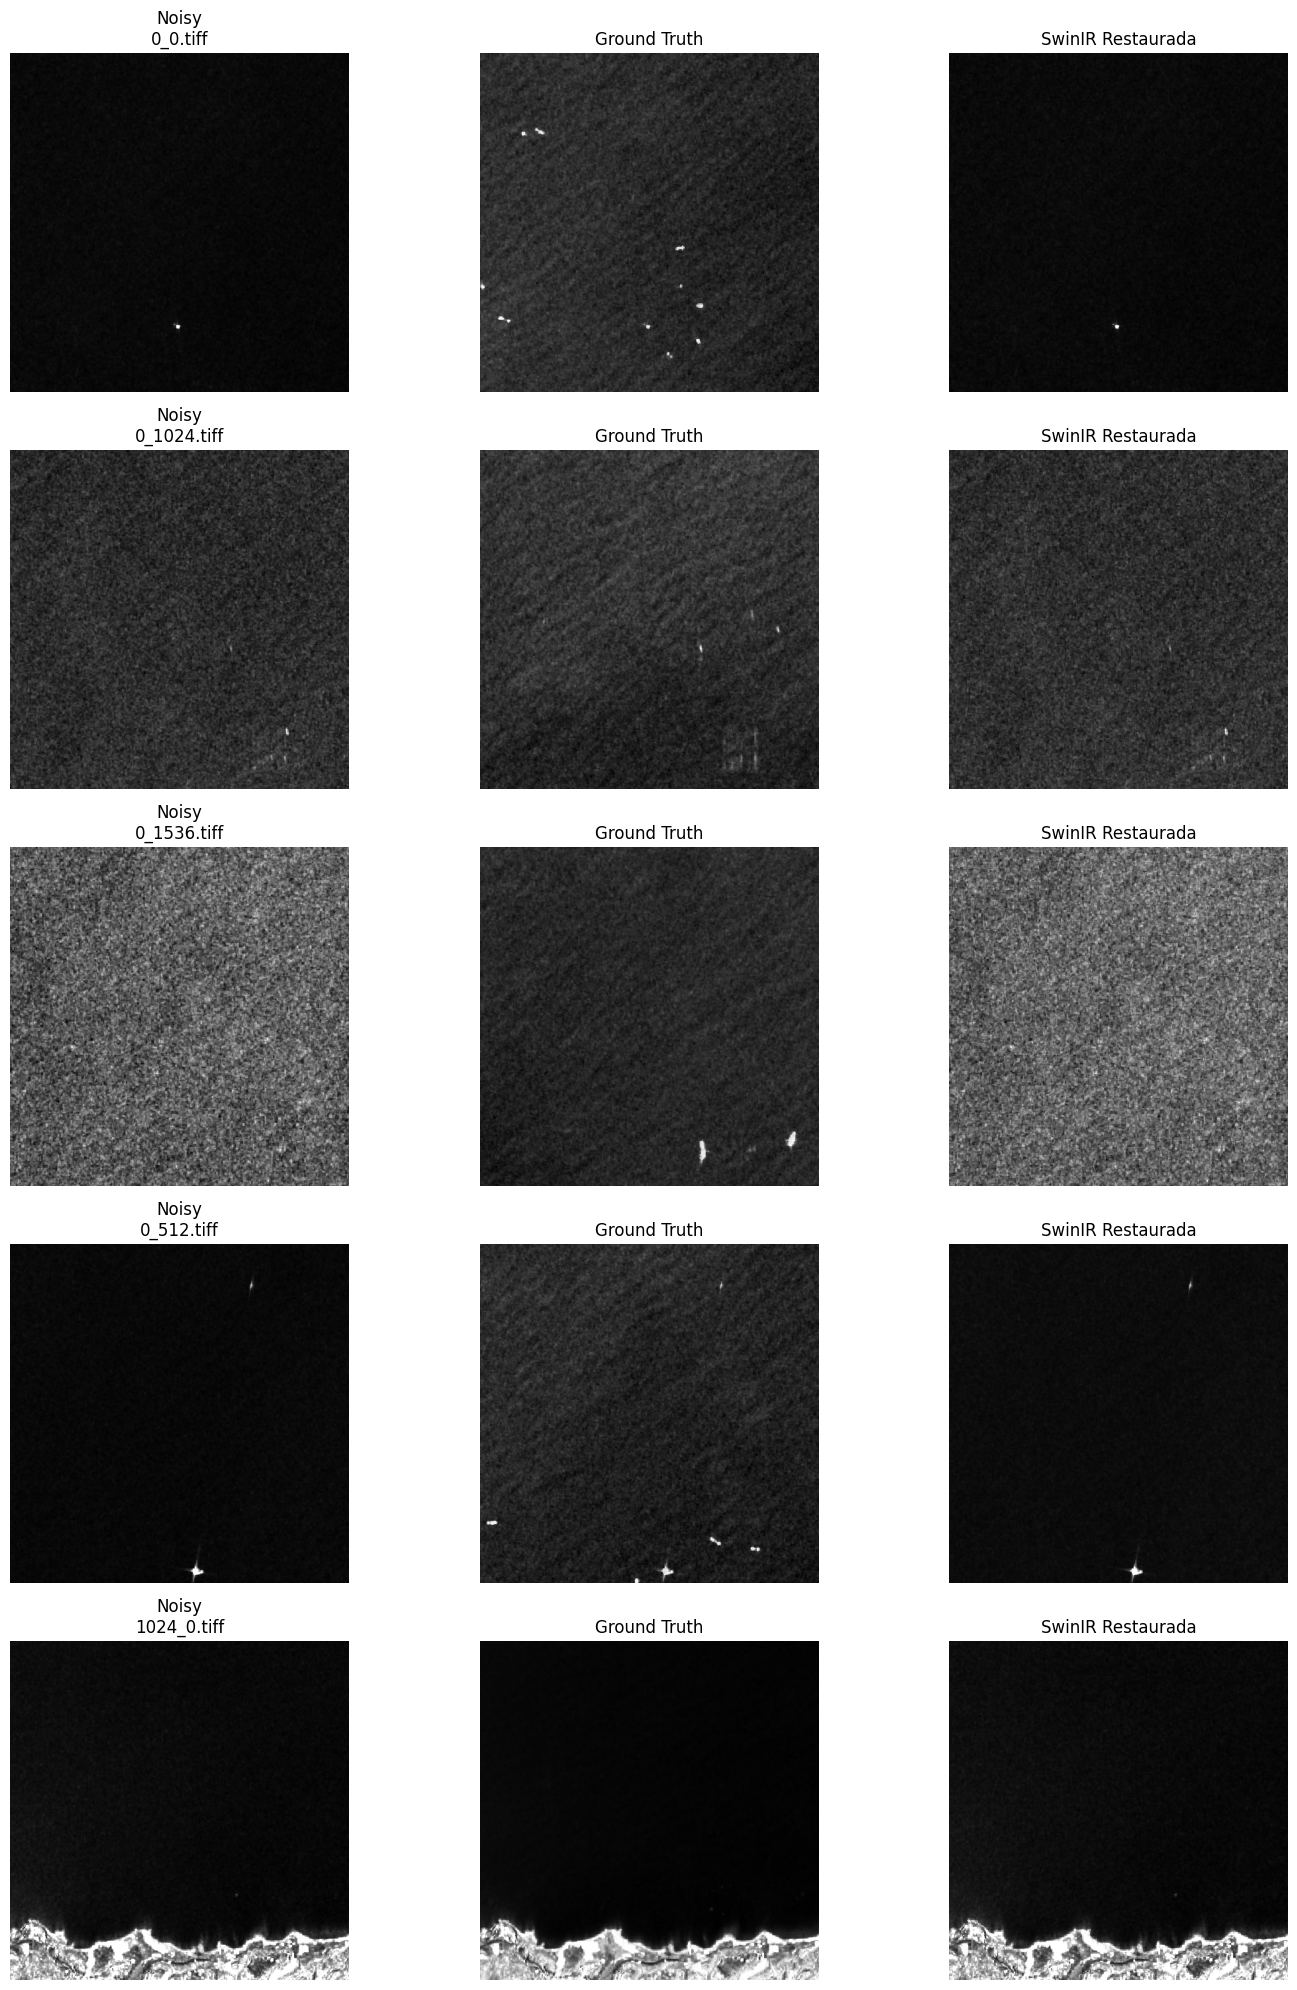

In [17]:
# ============================================================
# 15. VISUALIZAR RESULTADOS
# ============================================================

def mostrar_resultados_swinir(examples):
    n = len(examples)

    plt.figure(figsize=(15, 4 * n))

    for row, (filename, noisy_img, gtruth_img, restored_img) in enumerate(examples):
        plt.subplot(n, 3, row * 3 + 1)
        plt.imshow(noisy_img, cmap="gray")
        plt.title(f"Noisy\n{filename}")
        plt.axis("off")

        plt.subplot(n, 3, row * 3 + 2)
        plt.imshow(gtruth_img, cmap="gray")
        plt.title("Ground Truth")
        plt.axis("off")

        plt.subplot(n, 3, row * 3 + 3)
        plt.imshow(restored_img, cmap="gray")
        plt.title("SwinIR Restaurada")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


mostrar_resultados_swinir(visual_examples)

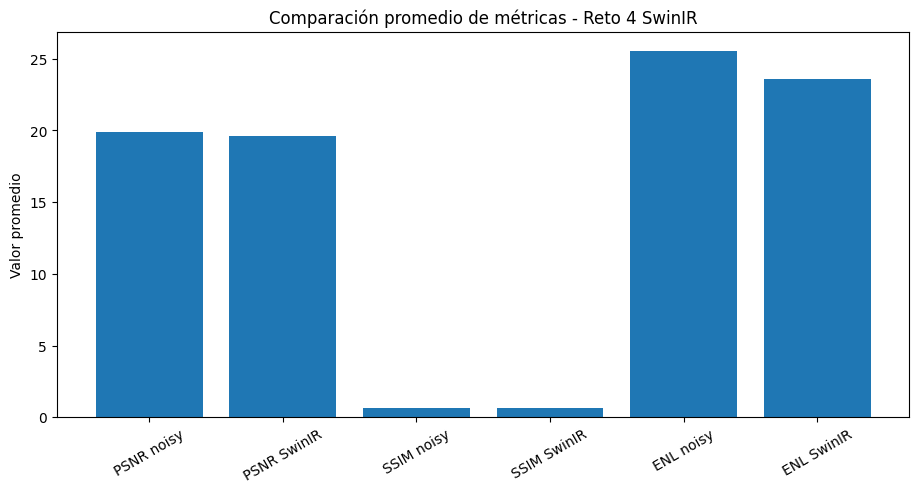

PSNR noisy: 19.9104
PSNR SwinIR: 19.6384
SSIM noisy: 0.6230
SSIM SwinIR: 0.6108
ENL noisy: 25.5769
ENL SwinIR: 23.6133


In [18]:
# ============================================================
# 16. GRÁFICA DE COMPARACIÓN DE MÉTRICAS
# ============================================================

metric_compare = {
    "PSNR noisy": df_metrics["PSNR_noisy"].mean(),
    "PSNR SwinIR": df_metrics["PSNR_swinir"].mean(),
    "SSIM noisy": df_metrics["SSIM_noisy"].mean(),
    "SSIM SwinIR": df_metrics["SSIM_swinir"].mean(),
    "ENL noisy": df_metrics["ENL_noisy"].mean(),
    "ENL SwinIR": df_metrics["ENL_swinir"].mean()
}

plt.figure(figsize=(11, 5))
plt.bar(metric_compare.keys(), metric_compare.values())
plt.title("Comparación promedio de métricas - Reto 4 SwinIR")
plt.xticks(rotation=30)
plt.ylabel("Valor promedio")
plt.show()

for k, v in metric_compare.items():
    print(f"{k}: {v:.4f}")

In [19]:
# ============================================================
# 17. GUARDAR EVIDENCIAS
# ============================================================

metrics_path = os.path.join(OUTPUT_PATH, "metricas_swinir.csv")
summary_path = os.path.join(OUTPUT_PATH, "resumen_metricas_swinir.csv")

df_metrics.to_csv(metrics_path, index=False)
summary_metrics.to_csv(summary_path)

print("Métricas guardadas en:", metrics_path)
print("Resumen guardado en:", summary_path)
print("Imágenes restauradas guardadas en:", RESTORED_PATH)

Métricas guardadas en: /content/drive/MyDrive/VISION-4/RETO4/evidencias_swinir/metricas_swinir.csv
Resumen guardado en: /content/drive/MyDrive/VISION-4/RETO4/evidencias_swinir/resumen_metricas_swinir.csv
Imágenes restauradas guardadas en: /content/drive/MyDrive/VISION-4/RETO4/evidencias_swinir/restored_tiff


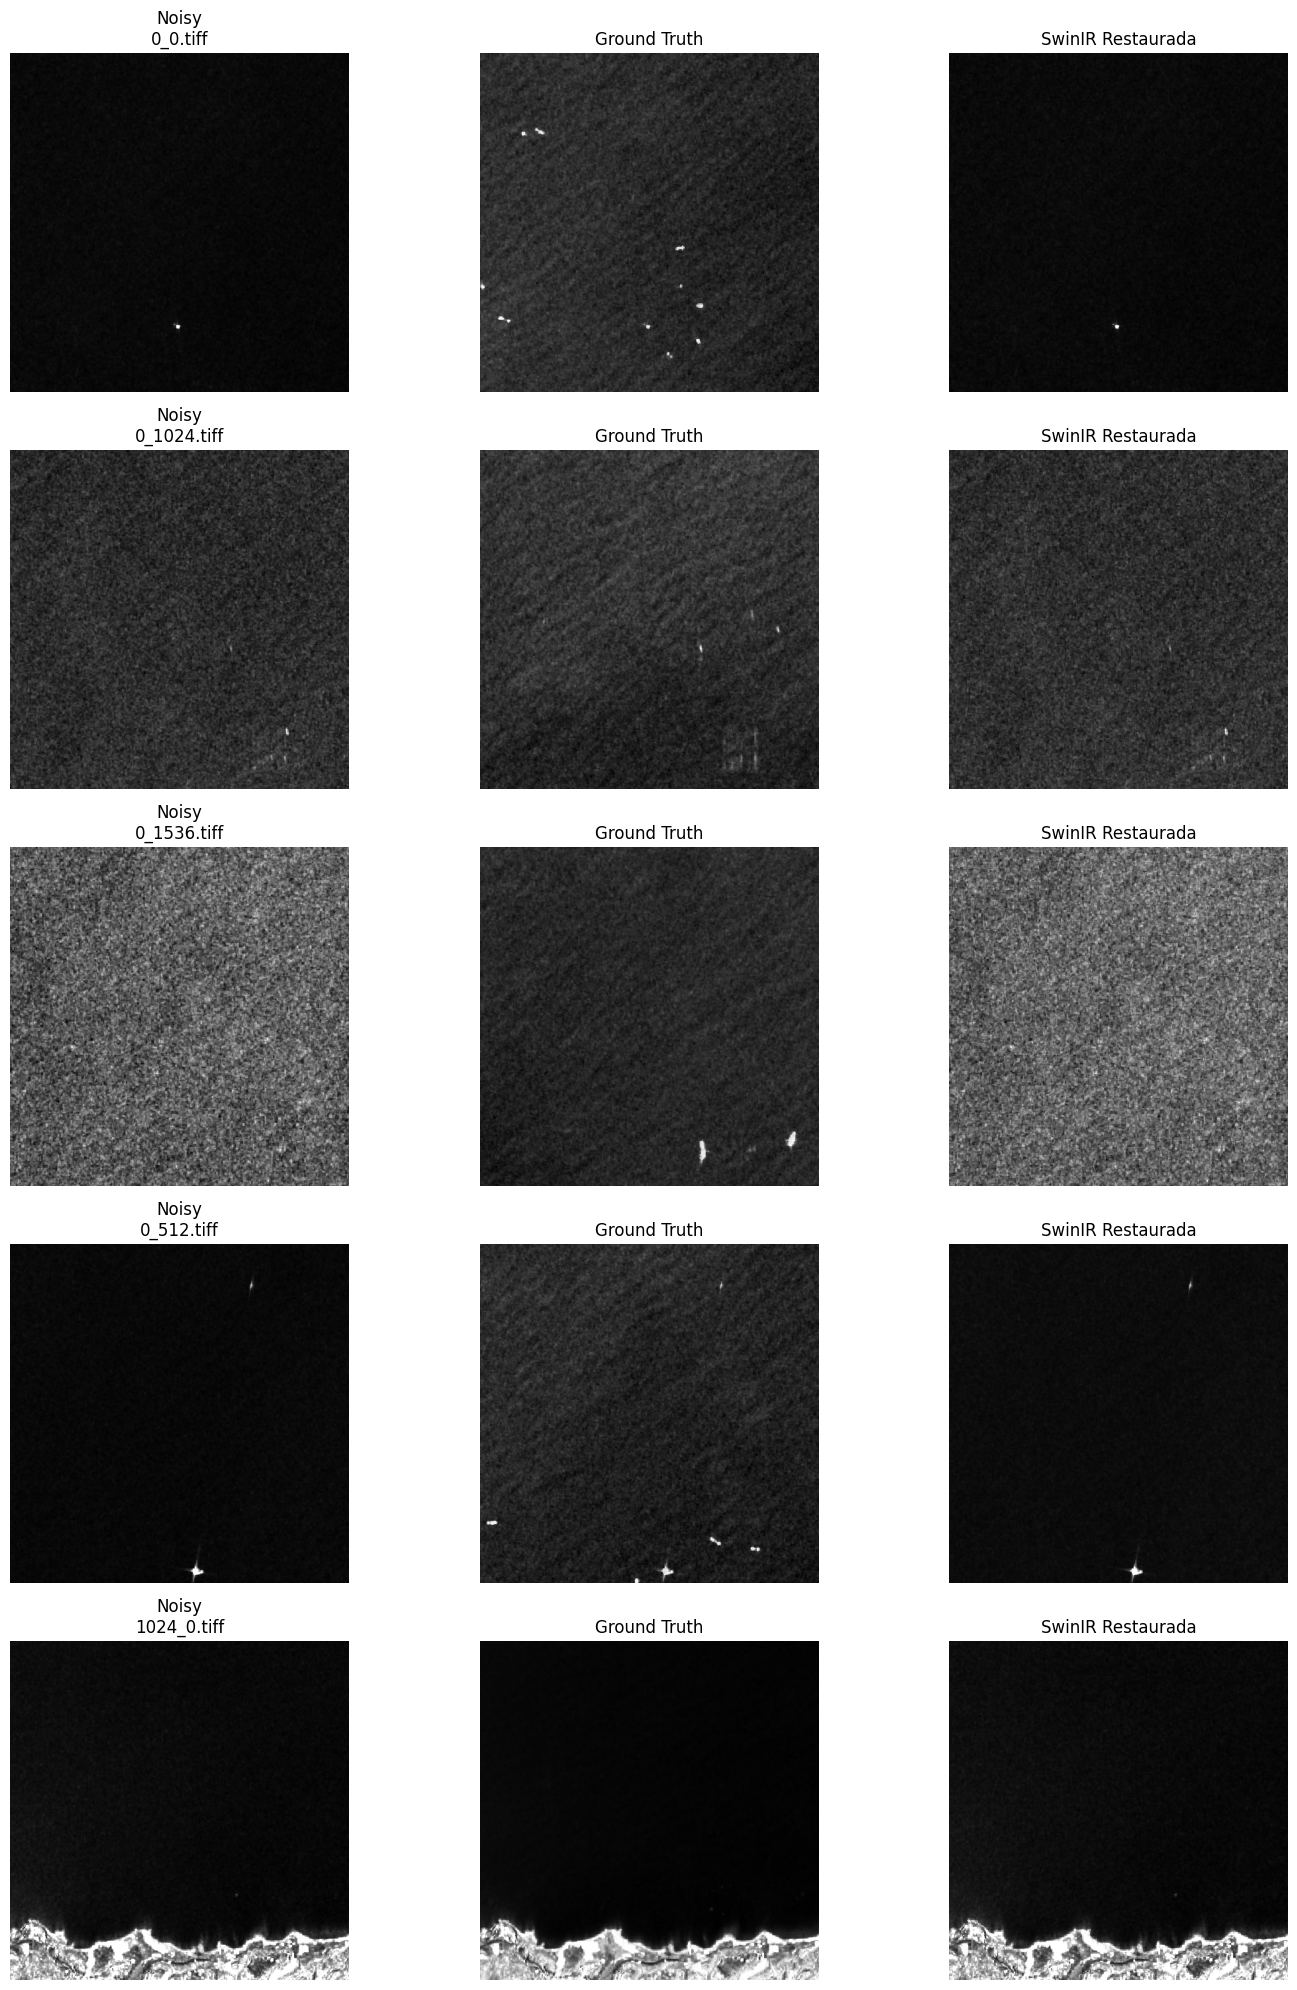

Figura guardada en: /content/drive/MyDrive/VISION-4/RETO4/evidencias_swinir/comparacion_visual_swinir.png


In [20]:
# ============================================================
# 18. GUARDAR FIGURA COMPARATIVA
# ============================================================

fig_path = os.path.join(OUTPUT_PATH, "comparacion_visual_swinir.png")

n = len(visual_examples)
plt.figure(figsize=(15, 4 * n))

for row, (filename, noisy_img, gtruth_img, restored_img) in enumerate(visual_examples):
    plt.subplot(n, 3, row * 3 + 1)
    plt.imshow(noisy_img, cmap="gray")
    plt.title(f"Noisy\n{filename}")
    plt.axis("off")

    plt.subplot(n, 3, row * 3 + 2)
    plt.imshow(gtruth_img, cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(n, 3, row * 3 + 3)
    plt.imshow(restored_img, cmap="gray")
    plt.title("SwinIR Restaurada")
    plt.axis("off")

plt.tight_layout()
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

print("Figura guardada en:", fig_path)